# 1.5 — Linear & Logistic Regression on *Real* Data

In **Lesson 01** we built linear and logistic regression by hand on **synthetic** data: we *invented* the true line (`TRUE_W`, `TRUE_B`), kept every input neatly in $[-3, 3]$, and never held any data back. That was the right way to learn the machinery — but real datasets are messier, and three habits that toy data lets you skip become essential:

1. **Standardize the features** — real columns live on wildly different scales (an age of `60` next to a ratio of `0.07`). A single learning rate cannot serve both, so we rescale every feature to mean 0, standard deviation 1.
2. **Split into train / test** — there is no `TRUE_W` to compare against, so we judge the model on data it has **never seen**.
3. **Evaluate with real metrics** — R² and RMSE for regression, accuracy for classification.

Everything *else* is identical to Lesson 01. The four-step loop — **model → loss → gradient → update** — and the finite-difference **gradient check** carry over unchanged. That is the whole point: the machinery you derived really does work on real problems.

We'll use two datasets that ship inside scikit-learn (no downloads): the **diabetes** dataset for regression and the **breast cancer Wisconsin** dataset for classification. As in Lesson 01, scikit-learn appears **only** to hand us the data and to *check our answers* — every model and every gradient is pure NumPy.


In [1]:
# Pure NumPy + matplotlib for everything we build.
# scikit-learn appears ONLY to (a) load real datasets and (b) check our work.
import numpy as np
import matplotlib.pyplot as plt

# Fix the random seed so the split and the numbers are reproducible every run.
rng = np.random.default_rng(0)

## Part 0: The from-scratch toolkit (carried over from Lesson 01)

So this notebook runs top-to-bottom on its own, we re-define the exact functions from Lesson 01. Read them as a refresher — nothing here is new:

- The **scalar** linear model (`predict`, `mse`, `mse_grad`) — used when we fit a single feature.
- The numerically-stable `sigmoid`, plus binary cross-entropy `bce` and its gradient `bce_grad` — the **vector** logistic model.
- `numeric_grad` — the finite-difference gradient check for a pair of scalars `(w, b)`.

Then we add the small **"real data" toolkit** this lesson is about: `standardize`, a *vector* linear model, a *vector* gradient check, and the metrics `r2` / `rmse`.

In [2]:
# --- Scalar linear model (Lesson 01, Parts 1-4) ---
def predict(x, w, b):
    """The model: turn input x into a prediction using parameters w, b."""
    return w * x + b

def mse(x, y, w, b):
    """Mean squared error of predictions against targets."""
    err = predict(x, w, b) - y
    return np.mean(err ** 2)

def mse_grad(x, y, w, b):
    """Analytic gradient of MSE w.r.t. (w, b)."""
    r = predict(x, w, b) - y          # residuals
    dw = 2 * np.mean(r * x)
    db = 2 * np.mean(r)
    return dw, db

def numeric_grad(f, w, b, eps=1e-6):
    """Central finite-difference gradient of a scalar function f(w, b)."""
    dw = (f(w + eps, b) - f(w - eps, b)) / (2 * eps)
    db = (f(w, b + eps) - f(w, b - eps)) / (2 * eps)
    return dw, db


# --- Vector logistic model (Lesson 01, Part 6) ---
def sigmoid(z):
    """Map logits to (0, 1); numerically stable for large |z|."""
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1 / (1 + np.exp(-z[pos]))
    exp_z = np.exp(z[~pos])
    out[~pos] = exp_z / (1 + exp_z)
    return out

def bce(X, y, w, b):
    """Binary cross-entropy loss."""
    p = sigmoid(X @ w + b)
    p = np.clip(p, 1e-12, 1 - 1e-12)        # avoid log(0)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def bce_grad(X, y, w, b):
    """Gradient of BCE: residual times input, just like linear regression."""
    r = sigmoid(X @ w + b) - y              # (predicted prob) - (true label)
    dw = X.T @ r / len(y)
    db = np.mean(r)
    return dw, db

### The new "real data" toolkit

Four small additions. The vector linear model is the scalar one written with a dot product — note how `mse_grad_vec` is the *same* `(prediction − target) × input` idea as `bce_grad`, just without the sigmoid. The vector gradient check nudges **each** weight component in turn. Standardization is fit on **training data only** so no information leaks from the test set.

In [3]:
# --- Vector linear model: the scalar model written with a dot product ---
def predict_vec(X, w, b):
    """Linear model for many features at once: each row of X dotted with w."""
    return X @ w + b

def mse_vec(X, y, w, b):
    """MSE for the vector model."""
    return np.mean((predict_vec(X, w, b) - y) ** 2)

def mse_grad_vec(X, y, w, b):
    """Vector gradient of MSE. Same (pred - target) * input, now as X.T @ r."""
    r = predict_vec(X, w, b) - y
    dw = 2 * X.T @ r / len(y)               # one partial derivative per feature
    db = 2 * np.mean(r)
    return dw, db

def numeric_grad_vec(f, w, b, eps=1e-6):
    """Finite-difference check when w is a VECTOR: nudge each component in turn."""
    dw = np.zeros_like(w)
    for i in range(len(w)):
        step = np.zeros_like(w)
        step[i] = eps
        dw[i] = (f(w + step, b) - f(w - step, b)) / (2 * eps)
    db = (f(w, b + eps) - f(w, b - eps)) / (2 * eps)
    return dw, db


# --- Standardization: fit stats on TRAIN, apply to both (no test-set leakage) ---
def standardize(train, test):
    """Rescale each column to mean 0, std 1 using TRAIN statistics only.
    Handles 1D or 2D arrays (returns same dimensionality as input).
    Uses population std (ddof=0), matching sklearn's StandardScaler convention."""
    mean = train.mean(axis=0)
    std  = train.std(axis=0, ddof=0)                                   # matches sklearn convention
    std  = np.where(std == 0, 1.0, std)                                 # guard: constant columns → 0
    return (train - mean) / std, (test - mean) / std, mean, std


# --- Metrics, by hand ---
def r2(y, yhat):
    """Coefficient of determination: 1 - (our error) / (error of predicting the mean)."""
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot

def rmse(y, yhat):
    """Root mean squared error, in the target's own units."""
    return np.sqrt(np.mean((y - yhat) ** 2))


## Part 1: Meet the data (diabetes)

The diabetes dataset records **10 physiological measurements** (age, BMI, blood pressure, six blood-serum values) for 442 patients, and a target: a continuous score of **disease progression one year later**. Our job: predict that score from the measurements.

First, two real-data chores:

- **Look at the data** — how many samples, what the features are, the scale of the target.
- **Split train / test** — we shuffle the rows, then hold back the last 20% as a test set we will *not* train on. Every score we report later is on this held-out set.

In [4]:
from sklearn.datasets import load_diabetes

data = load_diabetes()
X_all, y_all = data.data, data.target          # X_all: (442, 10), y_all: (442,)
print(f"X shape: {X_all.shape}   y shape: {y_all.shape}")
print(f"features: {list(data.feature_names)}")
print(f"target range: {y_all.min():.0f} to {y_all.max():.0f}   (disease progression)")

# Train/test split: shuffle row indices with our seeded rng, hold back the last 20%.
N = len(y_all)
perm = rng.permutation(N)
n_test = N // 5                                 # 20% for testing
test_idx, train_idx = perm[:n_test], perm[n_test:]

Xtr_all, Xte_all = X_all[train_idx], X_all[test_idx]
ytr, yte = y_all[train_idx], y_all[test_idx]
print(f"\ntrain samples: {len(ytr)}   test samples: {len(yte)}")

X shape: (442, 10)   y shape: (442,)
features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
target range: 25 to 346   (disease progression)

train samples: 354   test samples: 88


## Part 2: One real feature, the Lesson-01 way

To stay on familiar ground, we start with a **single feature: BMI** (body-mass index), the column most strongly tied to diabetes progression. With one feature, `w` and `b` are plain scalars and we can re-use Lesson 01's `predict` / `mse` / `mse_grad` **unchanged** — and we can plot the fit.

One new step: **standardize**. The raw BMI column is already pre-scaled in this dataset, but we standardize anyway (using train statistics) to build the habit and to keep the learning rate well-behaved.

In [5]:
bmi_col = data.feature_names.index("bmi")
x_tr_raw = Xtr_all[:, bmi_col]
x_te_raw = Xte_all[:, bmi_col]

# Standardize the single feature using TRAIN stats only.
x_tr, x_te, _, _ = standardize(x_tr_raw, x_te_raw)

# Gradient check FIRST — trust the gradient before training with it (Lesson 01 habit).
w0, b0 = 0.5, 100.0
ana = mse_grad(x_tr, ytr, w0, b0)
num = numeric_grad(lambda w, b: mse(x_tr, ytr, w, b), w0, b0)
print(f"analytic gradient: dw={ana[0]:.6f}, db={ana[1]:.6f}")
print(f"numeric  gradient: dw={num[0]:.6f}, db={num[1]:.6f}")
print(f"max abs difference: {max(abs(ana[0]-num[0]), abs(ana[1]-num[1])):.2e}")

analytic gradient: dw=-88.627255, db=-102.892655
numeric  gradient: dw=-88.627256, db=-102.892654
max abs difference: 1.05e-06


The gradient checks out, so we train with the **exact loop from Lesson 01**. Because the target lives around 150 (not near 0), we start `b` at the mean of the training targets — a small, sensible nudge so descent has less ground to cover.

learned: w=44.814, b=151.446
test R^2:  0.363
test RMSE: 61.55  (target ranges ~25 to 350)


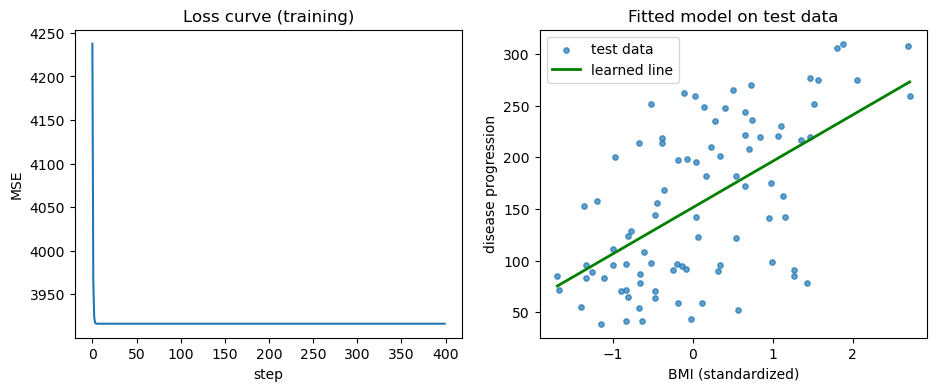

In [6]:
w, b = 0.0, ytr.mean()      # start the bias at the average target
lr = 0.3
steps = 400

loss_history = []
for step in range(steps):
    dw, db = mse_grad(x_tr, ytr, w, b)   # 1. gradient
    w -= lr * dw                         # 2. step downhill
    b -= lr * db
    loss_history.append(mse(x_tr, ytr, w, b))

# Evaluate on the held-out TEST set.
yte_hat = predict(x_te, w, b)
print(f"learned: w={w:.3f}, b={b:.3f}")
print(f"test R^2:  {r2(yte, yte_hat):.3f}")
print(f"test RMSE: {rmse(yte, yte_hat):.2f}  (target ranges ~25 to 350)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(loss_history); ax1.set_xlabel("step"); ax1.set_ylabel("MSE")
ax1.set_title("Loss curve (training)")
ax2.scatter(x_te, yte, s=15, alpha=0.7, label="test data")
order = np.argsort(x_te)
ax2.plot(x_te[order], predict(x_te[order], w, b), "g-", lw=2, label="learned line")
ax2.set_xlabel("BMI (standardized)"); ax2.set_ylabel("disease progression")
ax2.legend(); ax2.set_title("Fitted model on test data")
plt.show()

One feature already captures a real trend (higher BMI → faster progression), but an R² around **0.2–0.35** says most of the signal lives in the *other* nine features. Let's use them all.

## Part 3: All ten features (vectorize)

With many features, `w` becomes a **vector** — one weight per feature — and the prediction for one patient is the dot product $\hat{y} = \mathbf{w}\cdot\mathbf{x} + b$. Stacking all patients into a matrix $X$ of shape (N, 10), the whole batch is `X @ w + b`.

The gradient generalizes with no new calculus. Differentiating $\text{MSE} = \frac{1}{N}\sum r_i^2$ with respect to weight $w_j$ pulls out feature $j$ of each sample:

$$\frac{\partial \text{MSE}}{\partial w_j} = \frac{2}{N}\sum_i r_i\, x_{ij} \quad\Longrightarrow\quad \nabla_{\mathbf{w}}\text{MSE} = \frac{2}{N}\,X^\top \mathbf{r}$$

That is exactly `mse_grad_vec`. It is the **same** `(prediction − target) × input` rule as the scalar case — `X.T @ r` just does all ten dot products at once. We standardize every feature (train stats), gradient-check the vector form, train, and finally compare against `sklearn.linear_model.LinearRegression`.

In [7]:
# Standardize all 10 features using TRAIN statistics only.
Xtr, Xte, _, _ = standardize(Xtr_all, Xte_all)

# Vector gradient check at a random starting point.
w = rng.normal(size=Xtr.shape[1])
b = ytr.mean()
ana_w, ana_b = mse_grad_vec(Xtr, ytr, w, b)
num_w, num_b = numeric_grad_vec(lambda w, b: mse_vec(Xtr, ytr, w, b), w, b)
print(f"max abs diff (weights): {np.max(np.abs(ana_w - num_w)):.2e}")
print(f"abs diff (bias):        {abs(ana_b - num_b):.2e}")

max abs diff (weights): 4.08e-07
abs diff (bias):        2.62e-14


test R^2:  0.523
test RMSE: 53.26


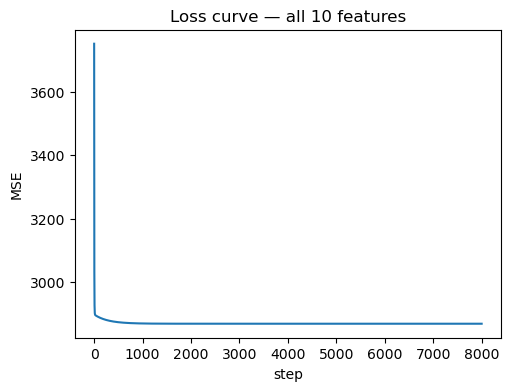

In [8]:
# Train the full linear model. Note the smaller lr: the diabetes serum features
# (s1-s6) are highly correlated, which steepens the loss surface, so lr=0.3 (fine
# for one feature) would now diverge. lr=0.1 stays stable.
w = np.zeros(Xtr.shape[1])
b = ytr.mean()
lr = 0.1
steps = 8000              # correlated features converge slowly; give it enough steps

loss_history = []
for step in range(steps):
    dw, db = mse_grad_vec(Xtr, ytr, w, b)
    w -= lr * dw
    b -= lr * db
    loss_history.append(mse_vec(Xtr, ytr, w, b))

yte_hat = predict_vec(Xte, w, b)
print(f"test R^2:  {r2(yte, yte_hat):.3f}")
print(f"test RMSE: {rmse(yte, yte_hat):.2f}")

plt.figure(figsize=(5.5, 4))
plt.plot(loss_history); plt.xlabel("step"); plt.ylabel("MSE")
plt.title("Loss curve — all 10 features"); plt.show()

### Cross-check against scikit-learn

`LinearRegression` solves for the best weights directly (no gradient descent). Our iterative answer should land on essentially the same coefficients and the same test R².

In [9]:
from sklearn.linear_model import LinearRegression

sk = LinearRegression().fit(Xtr, ytr)
print(f"ours    test R^2: {r2(yte, predict_vec(Xte, w, b)):.4f}")
print(f"sklearn test R^2: {r2(yte, sk.predict(Xte)):.4f}")
print(f"\nmax abs difference in coefficients: {np.max(np.abs(w - sk.coef_)):.4f}")
print(f"bias:  ours={b:.2f}   sklearn={sk.intercept_:.2f}")

ours    test R^2: 0.5226
sklearn test R^2: 0.5226

max abs difference in coefficients: 0.0000
bias:  ours=151.45   sklearn=151.45


## Part 4: Logistic regression on real data — two features + a decision boundary

Switch to **classification**. The breast cancer Wisconsin dataset has 30 features computed from cell-nucleus images of 569 tumors, each labeled **malignant (0)** or **benign (1)**. We predict that label.

As with the linear case, we warm up with **two** features so we can *see* the decision boundary: `mean radius` and `mean texture`. The model, loss, and gradient are Lesson 01's `sigmoid` / `bce` / `bce_grad` — completely unchanged.

In [10]:
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
Xc_all, yc_all = bc.data, bc.target            # (569, 30), labels 0/1
print(f"X shape: {Xc_all.shape}   classes: {bc.target_names}  (0={bc.target_names[0]}, 1={bc.target_names[1]})")

# Train/test split with the same recipe as before.
Nc = len(yc_all)
permc = rng.permutation(Nc)
nc_test = Nc // 5
cte_idx, ctr_idx = permc[:nc_test], permc[nc_test:]
Xctr_all, Xcte_all = Xc_all[ctr_idx], Xc_all[cte_idx]
yctr, ycte = yc_all[ctr_idx], yc_all[cte_idx]
print(f"train: {len(yctr)}   test: {len(ycte)}")

X shape: (569, 30)   classes: ['malignant' 'benign']  (0=malignant, 1=benign)
train: 456   test: 113


In [11]:
# Two features, standardized on train stats.
f1 = list(bc.feature_names).index("mean radius")
f2 = list(bc.feature_names).index("mean texture")
Xc2_tr, Xc2_te, _, _ = standardize(Xctr_all[:, [f1, f2]], Xcte_all[:, [f1, f2]])

# Gradient check the vector logistic gradient.
w = rng.normal(size=2)
b = 0.0
aw, ab = bce_grad(Xc2_tr, yctr, w, b)
nw, nb = numeric_grad_vec(lambda w, b: bce(Xc2_tr, yctr, w, b), w, b)
print(f"max abs diff (weights): {np.max(np.abs(aw - nw)):.2e}")
print(f"abs diff (bias):        {abs(ab - nb):.2e}")

max abs diff (weights): 6.57e-11
abs diff (bias):        1.13e-11


learned w=[-3.828 -1.007], b=0.716
test accuracy (2 features): 0.876


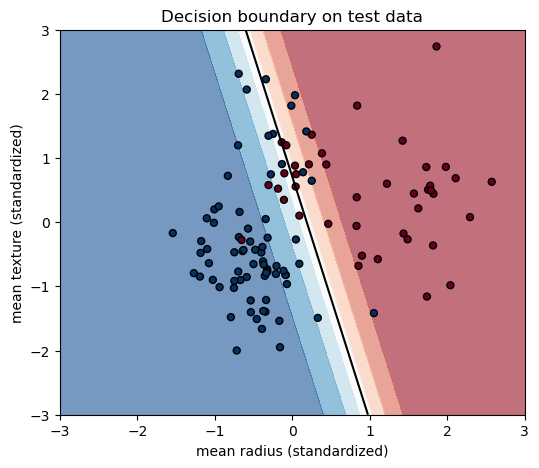

In [12]:
# Train the 2-feature classifier.
w = np.zeros(2)
b = 0.0
lr = 0.5
loss_history = []
for step in range(3000):
    dw, db = bce_grad(Xc2_tr, yctr, w, b)
    w -= lr * dw
    b -= lr * db
    loss_history.append(bce(Xc2_tr, yctr, w, b))

# Test accuracy: threshold the predicted probability at 0.5.
pte = sigmoid(Xc2_te @ w + b)
acc = np.mean((pte > 0.5) == ycte)
print(f"learned w={w.round(3)}, b={b:.3f}")
print(f"test accuracy (2 features): {acc:.3f}")

# Plot the training loss curve.
plt.figure(figsize=(5.5, 4))
plt.plot(loss_history); plt.xlabel("step"); plt.ylabel("BCE")
plt.title("Loss curve — 2-feature classifier"); plt.show()

# Decision boundary over the test points (Lesson 01 style).
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = sigmoid(grid @ w + b).reshape(xx.shape)
plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, zz, cmap="RdBu", alpha=0.6)
plt.contour(xx, yy, zz, levels=[0.5], colors="k")
plt.scatter(Xc2_te[:, 0], Xc2_te[:, 1], c=ycte, cmap="RdBu", edgecolors="k", s=25)
plt.xlabel("mean radius (standardized)"); plt.ylabel("mean texture (standardized)")
plt.title("Decision boundary on test data"); plt.show()


## Part 5: All 30 features (the full classifier)

Now use every feature. Nothing in the code changes except the width of `w` — the vector model already handles any number of features. We train, then cross-check against `sklearn.linear_model.LogisticRegression`. We pass a very large `C` (weak regularization) so sklearn is solving essentially the same un-penalized problem we are.

In [13]:
# Standardize all 30 features.
Xctr, Xcte, _, _ = standardize(Xctr_all, Xcte_all)

w = np.zeros(Xctr.shape[1])
b = 0.0
lr = 0.5
loss_history = []
for step in range(3000):
    dw, db = bce_grad(Xctr, yctr, w, b)
    w -= lr * dw
    b -= lr * db
    loss_history.append(bce(Xctr, yctr, w, b))

pte = sigmoid(Xcte @ w + b)
our_acc = np.mean((pte > 0.5) == ycte)

from sklearn.linear_model import LogisticRegression
skc = LogisticRegression(C=1e6, max_iter=10000).fit(Xctr, yctr)
print(f"ours    test accuracy: {our_acc:.3f}")
print(f"sklearn test accuracy: {skc.score(Xcte, ycte):.3f}")

# Plot the training loss curve.
plt.figure(figsize=(5.5, 4))
plt.plot(loss_history); plt.xlabel("step"); plt.ylabel("BCE")
plt.title("Loss curve — all 30 features"); plt.show()


ours    test accuracy: 0.956
sklearn test accuracy: 0.929


Our hand-written classifier matches scikit-learn's and reaches **~95%+** accuracy on tumors it never saw during training — using nothing but the `sigmoid → BCE → gradient → update` loop we derived by hand.

## Summary

We took the exact machinery from Lesson 01 and pointed it at two **real** datasets — and it just worked.

- **The four-step loop never changed.** Model → loss → gradient → update, identical to the toy version. All that real data demanded were three new *habits*, not new math:
  - **Standardize** features (train stats only) so one learning rate fits all columns.
  - **Split** train/test so every score is on unseen data.
  - **Evaluate** with real metrics — R²/RMSE for regression, accuracy for classification.
- **The gradient check still anchored our trust.** Before training each model — scalar or 30-dimensional — the analytic gradient agreed with finite differences to ~1e-6.
- **Scalar and vector are the same model.** `mse_grad_vec`'s `X.T @ r` is just the scalar `(pred − target) × input` rule applied to every feature at once — the same shape as `bce_grad`.
- **We matched scikit-learn** on both problems, confirming the from-scratch model is the real thing, not a toy.

**Next:**
- **Lesson 02 — Gradient Descent, deeply:** learning rate, loss surfaces, SGD vs. mini-batch, momentum, and Adam — why we fiddled with `lr` and starting points here.
- **Lesson 03 — The MLP & Backpropagation:** stack these neurons into layers and push the gradient backward through all of them.


## Exercises — Try These!

1. **Why standardize?** In Part 3, train on the **raw** features `Xtr_all` instead of the standardized `Xtr` (keep the same `lr`). Watch the loss explode to `inf`. Then find how small `lr` must become before it converges — that gap is exactly what standardization buys you.
2. **Swap the features.** In Part 4, replace `mean radius` / `mean texture` with two different columns from `bc.feature_names` and re-plot the boundary. Which pair separates the classes best?
3. **Precision and recall by hand.** From the Part 5 predictions, count true/false positives and negatives, then compute precision = `TP/(TP+FP)` and recall = `TP/(TP+FN)`. For a cancer screen, which matters more?
4. **Stretch — add L2 regularization.** Add a penalty $\frac{\lambda}{N}\lVert\mathbf{w}\rVert^2$ to the loss, work out its contribution to the gradient (it's `2*lam*w/N`), add that term to `mse_grad_vec`, and watch the weights shrink as you raise `lam`.
